In [1]:
import os
import cdflib # for cdf load 
import cdflib.cdfwrite
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, time, date
import matplotlib.pyplot as plt
import glob
from typing import Dict, Union
from apexpy import Apex
from chaosmagpy import load_CHAOS_matfile
from chaosmagpy.coordinate_utils import transform_points
from chaosmagpy.coordinate_utils import geo_to_gg
from chaosmagpy.data_utils import mjd2000, load_RC_datfile
from my_utils import load_cdf_file, load_folder_to_dataframe, mjd2000_to_datetime, datetime_to_mjd2000, gd2gc, gc2gd, my_chaos, downsample_to_1min, nez_to_gg, compute_declination
from baseline import BaselineEstimator, CoordinateRotator, VarianceEstimator, InverseCoordinateRotator
from IPython.display import clear_output
import supermag_api as sm


In [2]:
model = load_CHAOS_matfile('CHAOS-8.5.mat')

In [ ]:
def download_supermag(sta, year, month, baseline='yearly'):
    if month == 2:
        extent = 86400*28
        if year == 2024:
            extent = 86400*29
    elif month in [4, 6, 9, 11]:
        extent = 86400*30
    elif month in [1, 3, 5, 7, 8, 10, 12]:
        extent = 86400*31
    if sta=='PIF':
        sta='TAB'

    status, df_sup = sm.SuperMAGGetData(logon="yourid", start=[year,month,1,0,0], extent=extent, flagstring='baseline='+baseline, station=sta)
    if not df_sup.empty:
        for col in ['N', 'E', 'Z']:
            for system in ['nez', 'geo']:
                df_sup[f"{col}_{system}"] = [row[system] for row in df_sup[col]]
        df_sup = df_sup.drop(columns=['N', 'E', 'Z'])

        df_sup['tval'] = pd.to_datetime(df_sup['tval'], unit='s')
        df_sup = df_sup.rename(columns={'tval': 'time', 'N_nez': 'dbn_nez', 'E_nez': 'dbe_nez', 'Z_nez': 'dbz_nez', 'N_geo': 'dbn_geo', 'E_geo': 'dbe_geo', 'Z_geo': 'dbz_geo'})
        cols = ['dbn_nez','dbn_geo','dbe_nez','dbe_geo','dbz_nez','dbz_geo']
        df_sup[cols] = df_sup[cols].where(df_sup[cols] < 9999, np.nan) #
    
    return status, df_sup



In [ ]:
status, df_sup = sm.SuperMAGGetData(logon="yourid", start=[2024,11,1,0,0], extent=86400, flagstring='baseline=yearly', station='TAB')
if not df_sup.empty:
    for col in ['N', 'E', 'Z']:
        for system in ['nez', 'geo']:
            df_sup[f"{col}_{system}"] = [row[system] for row in df_sup[col]]
    df_sup = df_sup.drop(columns=['N', 'E', 'Z'])

In [5]:
df_sup

,tval,ext,iaga,N_nez,N_geo,E_nez,E_geo,Z_nez,Z_geo
0,1.704326e+09,60.0,GDH,-6.600586,2.788345,17.482918,18.478238,-2.582031,-2.582031
1,1.704326e+09,60.0,GDH,-3.210938,6.190853,18.394211,17.616199,-1.660156,-1.660156
2,1.704327e+09,60.0,GDH,-1.746094,6.985674,17.406046,16.038068,-3.742188,-3.742188
3,1.704327e+09,60.0,GDH,-1.272461,7.180250,16.958858,15.416421,-7.109375,-7.109375
4,1.704327e+09,60.0,GDH,-3.243164,3.923899,13.814384,13.636653,-12.171875,-12.171875
...,...,...,...,...,...,...,...,...,...
1435,1.704412e+09,60.0,GDH,-17.928711,-52.764670,-75.944870,-57.488708,42.101562,42.101562
1436,1.704413e+09,60.0,GDH,-28.401367,-61.824813,-75.789413,-52.233757,39.691406,39.691406
1437,1.704413e+09,60.0,GDH,-30.451172,-62.985889,-74.506485,-50.112553,47.492188,47.492188
1438,1.704413e+09,60.0,GDH,-46.991211,-75.446953,-70.480263,-38.514914,51.640625,51.640625


In [5]:
def rotation_manual(df_data, df_ref):
    """
    Rotate (X, Y) to best match reference (X_ref, Y_ref).
    
    Returns
    -------
    X_rot : np.ndarray   - rotated X component
    Y_rot : np.ndarray   - rotated Y component
    theta_deg : float    - optimal rotation angle in degrees
    """

    cols_to_smooth = ['X','Y','Z']
    df_data_ds = downsample_to_1min(df_data[cols_to_smooth], input_rate="1s", nan_threshold=0.5)
    X = df_data_ds['X'].values
    Y = df_data_ds['Y'].values
    X_sec = df_data['X'].values
    Y_sec = df_data['Y'].values
    
    df_ref = downsample_to_1min(df_ref[cols_to_smooth], input_rate="1s", nan_threshold=0.5)
    df_ref = df_ref.reset_index()
    df_ref=df_ref[df_ref['time'].isin(df_data_ds.index)]
    X_ref = df_ref['X'].values
    Y_ref = df_ref['Y'].values

    def apply_rotation(theta_deg):
        theta = theta_deg * np.pi / 180
        rot = np.array([[ np.cos(theta), -np.sin(theta)],
                        [ np.sin(theta),  np.cos(theta)]])
        YX_rot = rot @ np.vstack([Y, X])
        return YX_rot[0, :], YX_rot[1, :]   # Y_rot, X_rot
    
    def apply_rotation_final(theta_deg):
        theta = theta_deg * np.pi / 180
        rot = np.array([[ np.cos(theta), -np.sin(theta)],
                        [ np.sin(theta),  np.cos(theta)]])
        YX_rot = rot @ np.vstack([Y_sec, X_sec])
        return YX_rot[0, :], YX_rot[1, :]   # Y_rot, X_rot

    def variance_at(theta_deg):
        Y_rot, X_rot = apply_rotation(theta_deg)
        return np.nanvar(X_ref - X_rot) + np.nanvar(Y_ref - Y_rot)

    # --- Coarse pass: -90° to +90° in 10° steps --------------------
    coarse_angles = np.arange(-90.0, 91.0, 10)
    coarse_vars   = [variance_at(t) for t in coarse_angles]
    best_coarse   = coarse_angles[np.argmin(coarse_vars)]

    # --- Fine pass: ±5° around best coarse angle in 1° steps --------
    fine_angles = np.arange(best_coarse - 5, best_coarse + 5.1, 1)
    fine_vars   = [variance_at(t) for t in fine_angles]
    best_theta  = fine_angles[np.argmin(fine_vars)]

    Y_rot, X_rot = apply_rotation_final(best_theta)

    return X_rot, Y_rot, best_theta


In [6]:
def rotation_sup(df_data, df_sup):
    """
    Rotate (X, Y) to best match reference (X_ref, Y_ref).
    
    Returns
    -------
    X_rot : np.ndarray   - rotated X component
    Y_rot : np.ndarray   - rotated Y component
    theta_deg : float    - optimal rotation angle in degrees
    """

    cols_to_smooth = ['X','Y','Z']
    df_data_ds = downsample_to_1min(df_data[cols_to_smooth], input_rate="1s", nan_threshold=0.5)
    df_data_ds=df_data_ds[df_data_ds.index.isin(df_sup['time'].values)]

    X = df_data_ds['X'].values
    Y = df_data_ds['Y'].values
    X_sec = df_data['X'].values
    Y_sec = df_data['Y'].values
    
    df_sup=df_sup[df_sup['time'].isin(df_data_ds.index)]
    X_ref = df_sup['dbn_geo'].values
    Y_ref = df_sup['dbe_geo'].values

    def apply_rotation(theta_deg):
        theta = theta_deg * np.pi / 180
        rot = np.array([[ np.cos(theta), -np.sin(theta)],
                        [ np.sin(theta),  np.cos(theta)]])
        YX_rot = rot @ np.vstack([Y, X])
        return YX_rot[0, :], YX_rot[1, :]   # Y_rot, X_rot
    
    def apply_rotation_final(theta_deg):
        theta = theta_deg * np.pi / 180
        rot = np.array([[ np.cos(theta), -np.sin(theta)],
                        [ np.sin(theta),  np.cos(theta)]])
        YX_rot = rot @ np.vstack([Y_sec, X_sec])
        return YX_rot[0, :], YX_rot[1, :]   # Y_rot, X_rot

    def variance_at(theta_deg):
        Y_rot, X_rot = apply_rotation(theta_deg)
        return np.nanvar(X_ref - X_rot) + np.nanvar(Y_ref - Y_rot)

    # --- Coarse pass: -90° to +90° in 10° steps --------------------
    coarse_angles = np.arange(-90.0, 91.0, 10)
    coarse_vars   = [variance_at(t) for t in coarse_angles]
    best_coarse   = coarse_angles[np.argmin(coarse_vars)]

    # --- Fine pass: ±5° around best coarse angle in 1° steps --------
    fine_angles = np.arange(best_coarse - 5, best_coarse + 5.1, 1)
    fine_vars   = [variance_at(t) for t in fine_angles]
    best_theta  = fine_angles[np.argmin(fine_vars)]

    Y_rot, X_rot = apply_rotation_final(best_theta)

    return X_rot, Y_rot, best_theta


In [7]:
from scipy.interpolate import CubicSpline

def interpolate_declination_fast(rotator, t_target):
    """
    Interpolate the smoothed declination onto arbitrary target timestamps
    using scipy CubicSpline instead of the slow per-sample Python loop.

    Parameters
    ----------
    rotator : CoordinateRotator
        A rotator that has already run up to smooth_declination().
    t_target : array-like of datetime64 or Timestamps
        The timestamps to interpolate onto (e.g. your 1-second grid).

    Returns
    -------
    q : np.ndarray
        Declination values at each target timestamp.
    """
    t_nodes = rotator.q_daily.index.values.astype("datetime64[s]").astype(float)
    y_nodes = rotator.q_smooth

    # Only interpolate over the valid node range; extrapolate as constant
    cs = CubicSpline(t_nodes, y_nodes, extrapolate=False)

    t_full = pd.to_datetime(t_target).values.astype("datetime64[s]").astype(float)
    q = cs(t_full)

    # Fill any out-of-range extrapolation with edge values
    q = np.where(t_full < t_nodes[0],  y_nodes[0],  q)
    q = np.where(t_full > t_nodes[-1], y_nodes[-1], q)

    return q

In [8]:
def chaos_rotation(y_m, folder, GLON, GLAT, model):
    year = y_m.year
    month = y_m.month
    month_str = str(month).zfill(2)

    folder_data = f'dtu_downloads/{folder}/{year}/'
    
    sta = folder[0:3]

    apex_obj = Apex(date=datetime(year, month, 12), refh=0)
    mlat = apex_obj.convert(GLAT, GLON, "geo", "apex", height=0)[0]
    mlat = mlat[0]

    cdf_files = glob.glob(os.path.join(folder_data, f'*{year}{month_str}*.cdf'))
    df_data = []
    for filepath in cdf_files:
        filename = os.path.basename(filepath)
        try:
            X, Y, Z, t_mjd = load_cdf_file(filepath)
            time = mjd2000_to_datetime(t_mjd)
            df = pd.DataFrame({'X':X,'Y':Y,'Z':Z,'t_mjd':t_mjd,'time':time})

            df_data.append(df)

        except Exception as e:
            print(f"Warning: Failed to load {filename}: {e}")

    df_data = pd.concat(df_data, ignore_index=True)
    df_data = df_data.sort_values(by='time', ignore_index=True)
    df_data.set_index('time', inplace=True)

    cols_to_smooth = ['X','Y','Z']
    df_data_ds = downsample_to_1min(df_data[cols_to_smooth], input_rate="1s", nan_threshold=0.5)

    # --- Step 1: Estimate declination on 1-minute data (fast) ---
    rotator_1min = CoordinateRotator(df_data_ds.index.to_numpy(), df_data_ds['X'].to_numpy(), df_data_ds['Y'].to_numpy(), df_data_ds['Z'].to_numpy())
    rotator_1min.df["datetime"] = pd.to_datetime(rotator_1min.df["datetime"])

    rotator_1min.rotate()
    bn, be, bu = rotator_1min.get_components()

    # Estimate declination on 1-minute data as before
    rotator_1min.get_declination_raw()
    rotator_1min.get_declination_daily()
    rotator_1min.smooth_declination()
    # Skip interpolate_declination() entirely

    # Interpolate fast onto 1-second timestamps
    q_1sec = interpolate_declination_fast(rotator_1min, df_data.index.values)

    # Apply rotation directly
    x = np.asarray(df_data['X'].to_numpy(), dtype=float)
    y = np.asarray(df_data['Y'].to_numpy(), dtype=float)
    z = np.asarray(df_data['Z'].to_numpy(), dtype=float)
    bn_sec = x * np.cos(q_1sec) + y * np.sin(q_1sec)
    be_sec = -x * np.sin(q_1sec) + y * np.cos(q_1sec)
    bu_sec = z


    ve = VarianceEstimator(df_data_ds.index.to_numpy(), bn, be, bu, mlat)
    ve.estimate()

    # Estimate baselines for all three rotated components
    be_e = BaselineEstimator(df_data_ds.index.to_numpy(), be, ve.df["uE"].values, mlat, component="E")
    be_e.get_baseline()

    be_n = BaselineEstimator(df_data_ds.index.to_numpy(), bn, ve.df["uN"].values, mlat, component="N")
    be_n.get_baseline()

    be_u = BaselineEstimator(df_data_ds.index.to_numpy(), bu, ve.df["uZ"].values, mlat, component="Z")
    be_u.get_baseline()

    QY_n_min = be_n.df["QY"].values
    QY_e_min = be_e.df["QY"].values
    QY_u_min = be_u.df["QY"].values
    
    t_nodes = be_n.df["datetime"].values.astype('datetime64[s]').astype(float)
    t_full = df_data.index.values.astype('datetime64[s]').astype(float)

    QY_n = np.interp(t_full, t_nodes, QY_n_min)
    QY_e = np.interp(t_full, t_nodes, QY_e_min)
    QY_u = np.interp(t_full, t_nodes, QY_u_min)

    dbn_nez = bn_sec - QY_n
    dbe_nez = be_sec - QY_e
    dbz_nez = bu_sec - QY_u

    df_out = df_data.copy()
    df_out = df_out.reset_index()
    df_out['time'] = pd.to_datetime(df_out['time'])
    df_out['time'] = df_out['time'].astype('datetime64[ns]')

    D = compute_declination(GLAT, GLON, 0, 8700.0, model)
    theta = -D[0] * np.pi/180
    rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
    YXrot = rot@np.vstack([dbe_nez, dbn_nez])
    Y_rot = YXrot[0,:]
    X_rot = YXrot[1,:]

    df_out['X'] = X_rot
    df_out['Y'] = Y_rot
    df_out['Z'] = dbz_nez

    return df_out, -D[0]



In [ ]:
times = np.load('concurrent_times_dtu.npy',allow_pickle=True)

# If your array is in datetime64[D] or finer resolution, cast to month precision first
year_months = times.astype('datetime64[M]')

unique_year_months = np.unique(year_months)
unique_year_months = pd.DatetimeIndex(unique_year_months)

df_loc = pd.read_csv('dtu_stations.csv')
folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']
#folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m','SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']

In [ ]:
failed_downloads = np.load('failed_downloads_rotation.npy')
failed_downloads = np.array([])
df_theta = pd.read_pickle('data_frames/df_rotation.pkl')

for folder in folders:
        
    for y_m in unique_year_months:
        sup1 = False
        sup2 = False
        sup3 = False
        chaos0 = False

        year = y_m.year
        month = y_m.month

        sta = folder[0:3]
        print(f'Starting {sta} {year} month {month}...')

        folder_data = f'dtu_downloads/yearly_BASELINE/{folder}/'
        folder_out = f'dtu_downloads/yearly_BASELINE_rotated/{folder}/'
        file_name = f'dtu_{sta}_{year}_{month}.parquet'
        file_path_data = folder_data + file_name
        file_path_out = folder_out + file_name

        if not os.path.exists(folder_out):
            os.makedirs(folder_out)
        
        if os.path.exists(file_path_out):
            print(f'File for {sta} in month {month} already exists')
            continue

        GLON = df_loc[df_loc['IAGA']==sta]['lon_gd'].values
        GLAT = df_loc[df_loc['IAGA']==sta]['lat_gd'].values

        df_data = pd.read_parquet(file_path_data, engine='fastparquet')
        df_out = df_data.copy()
        df_data.set_index('time', inplace=True)

        file_path_sup1 = f'supermag_downloads/yearly_BASELINE/{year}/supermag_{sta}_{year}_{month}.csv'
        file_path_sup2 = f'supermag_downloads/yearly_baseline/{year}/supermag_{sta}_{year}_{month}.csv'
        
        if os.path.exists(file_path_sup1):
            sup1 = True
            df_sup = pd.read_csv(file_path_sup1)
            df_sup['time'] = pd.to_datetime(df_sup['time'])
            df_sup['t_mjd'] = datetime_to_mjd2000(df_sup['time'].values)
            print('Using sup1...')

        elif os.path.exists(file_path_sup2):
            sup2 = True
            df_sup = pd.read_csv(file_path_sup2)
            df_sup['time'] = pd.to_datetime(df_sup['time'])
            df_sup['t_mjd'] = datetime_to_mjd2000(df_sup['time'].values)
            print('Using sup2...')
        else:
            print('Attempting SuperMAG download...')
            try:
                status, df_sup = download_supermag(sta, year, month, baseline='yearly')
            except:
                print('SuperMAG download failed! Skipping for now...')
                print('Adding filename to list of failed downloads...')
                failed_downloads = np.append(failed_downloads, file_name)
                np.save('failed_downloads_rotation.npy', failed_downloads)
                df_theta.loc[y_m, folder] = np.nan
                df_theta.to_pickle('data_frames/df_rotation.pkl')
                continue
            if status:
                if not df_sup.empty:
                    sup3 = True
                    df_sup.to_csv(file_path_sup2)
                    print('Download successful. Using sup3...')
                else:
                    chaos0 = True
                    print('Using chaos0...')
            else:
                chaos0 = True
                print('Using chaos0...')
        if sup1 or sup2 or sup3:
            print('Applying SuperMAG rotation...')
            X_rot, Y_rot, theta = rotation_sup(df_data, df_sup)
            df_out['X'] = X_rot
            df_out['Y'] = Y_rot
            df_theta.loc[y_m, folder] = theta
            df_out.to_parquet(file_path_out, engine='fastparquet')
            df_theta.to_pickle('data_frames/df_rotation.pkl')
            print(f'SuperMAG rotation done for {sta} in {year} month {month}!')
            print(f'Rotation angle: {theta} degrees')

        elif chaos0:
            print('Applying CHAOS rotation...')
            df_out, theta = chaos_rotation(y_m, folder, GLON, GLAT, model)
            df_theta.loc[y_m, folder] = theta
            df_out.to_parquet(file_path_out, engine='fastparquet')
            df_theta.to_pickle('data_frames/df_rotation.pkl')
            print(f'CHAOS rotation done for {sta} in {year} month {month}!')
            print(f'Rotation angle: {theta} degrees')
            


df_theta.to_pickle('data_frames/df_rotation_final.pkl')

In [9]:
df_theta = pd.read_pickle('data_frames/df_rotation.pkl')
df_theta

,GDH6,KUL2,KUV1,NAQ4m,NRD2,PIF4,SCO2,SKT1,STF2,SUM1,SVS1
2023-02-01,1.0,20.419344,-41.0,-3.0,11.969648,0.0,NaN,-30.0,5.0,-7.0,-47.0
2023-03-01,0.0,20.419344,-42.0,-3.0,11.969648,0.0,NaN,-30.0,-31.0,-7.0,-47.0
2023-04-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-05-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-06-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-07-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-08-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-09-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0
2023-10-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-32.0,-7.0,-47.0
2023-11-01,0.0,20.419344,-41.0,-3.0,NaN,0.0,14.49083,-30.0,-31.0,-7.0,-47.0


**MANUAL CHAOS ROTATION**

In [ ]:
folder = 'SCO2'
for y_m in df_theta[folder].index:
    angle = df_theta.loc[y_m,folder]
    if not np.isnan(angle):
        print(f'Skipping {y_m.year} month {y_m.month}')
        continue

    month = y_m.month
    year = y_m.year
    sta = folder[0:3]
    GLON = df_loc[df_loc['IAGA']==sta]['lon_gd'].values
    GLAT = df_loc[df_loc['IAGA']==sta]['lat_gd'].values

    folder_out = f'dtu_downloads/yearly_BASELINE_rotated/{folder}/'
    file_name = f'dtu_{sta}_{year}_{month}_test.parquet'
    file_path_out = folder_out + file_name

    df_out, theta = chaos_rotation(y_m, folder, GLON, GLAT, model)
    df_theta.loc[y_m, folder] = theta
    df_out.to_parquet(file_path_out, engine='fastparquet')
    df_theta.to_pickle('data_frames/df_rotation.pkl')
    print(f'CHAOS rotation done for {sta} in {year} month {month}!')
    print(f'Rotation angle: {theta} degrees')
    

In [15]:
folder='SCO2'
sta_str = folder[0:3]
df_data = pd.read_parquet(f'dtu_downloads/yearly_BASELINE/{folder}/dtu_{sta_str}_2024_10.parquet', engine='fastparquet')
df_ref = pd.read_parquet(f'dtu_downloads/yearly_BASELINE_rotated/{folder}/dtu_{sta_str}_2024_10.parquet', engine='fastparquet')
#df_test = pd.read_parquet(f'dtu_downloads/yearly_BASELINE_rotated/{folder}/dtu_{sta_str}_2023_3_test.parquet', engine='fastparquet')
#df_sup = pd.read_csv(f'supermag_downloads/yearly_baseline/2024/supermag_{sta_str}_2023_3.csv')
#df_sup['time'] = pd.to_datetime(df_sup['time'])
#df_sup['t_mjd'] = datetime_to_mjd2000(df_sup['time'].values)
df_data.set_index('time', inplace=True)
df_ref.set_index('time', inplace=True)
#df_test.set_index('time', inplace=True)

In [25]:
D = compute_declination(76.02, 294.90, 0, 9300, model)
theta = -D[0] * np.pi/180

Y_nez_rot,X_nez_rot = apply_rotation_manual(df_sup['dbn_nez'].values,df_sup['dbe_nez'].values, -D[0])

In [16]:
X_rot, Y_rot, theta = rotation_manual(df_data, df_ref)
theta

np.float64(14.0)

In [24]:
sup = pd.read_csv('supermag_downloads/yearly_baseline/2023/supermag_SUM_2023_10.csv')
sup['time'] = pd.to_datetime(sup['time'])
sup['t_mjd'] = datetime_to_mjd2000(sup['time'].values)
dtu = pd.read_parquet('dtu_downloads/yearly_BASELINE_rotated/SUM1/dtu_SUM_2023_10.parquet', engine='fastparquet')

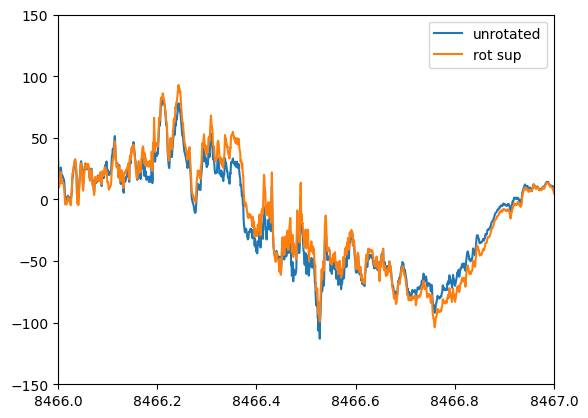

In [40]:
vardtu, varsup = 'X', 'dbn_geo'
plt.plot(df_data['t_mjd'].values[::60],df_data[vardtu].values[::60], label='unrotated')
plt.plot(df_ref['t_mjd'].values[::60],df_ref[vardtu].values[::60]+1, label='rot sup')
#plt.plot(df_test['t_mjd'].values[::60],df_test[vardtu].values[::60], label='rot chaos')
#plt.plot(df_sup['t_mjd'],df_sup[varsup], label='supermag')
#plt.plot(df_sup['t_mjd'],X_nez_rot, label='supermag nez rot')
#plt.plot(df_test['t_mjd'].values[::60],Y_rot[::60], ls='--',label='rot chaos 2')
#plt.plot(df_data['t_mjd'].values[::60],X_rot[::60], ls='--')
plt.xlim((8466,8467))
plt.ylim((-150,150))
plt.legend()
plt.show()

**MANUAL MANUAL ROTATION**

In [2]:
def apply_rotation_manual(X,Y,theta_deg):
    theta = theta_deg * np.pi / 180
    rot = np.array([[ np.cos(theta), -np.sin(theta)],
                    [ np.sin(theta),  np.cos(theta)]])
    YX_rot = rot @ np.vstack([Y, X])
    return YX_rot[0, :], YX_rot[1, :]   # Y_rot, X_rot

In [14]:

folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'SUM1']

angle_opt = [1.0, 0, -41.0, -3.0, 0, 0,	0, -30.0, 5.0, -7.0, -47.0]

for folder, angle in zip(folders, angle_opt):

    sta = folder[0:3]

    folder_out = f'dtu_downloads/yearly_BASELINE_rotated/{folder}/'
    folder_data = f'dtu_downloads/yearly_BASELINE/{folder}/'
    file_name = f'dtu_{sta}_2026_5.parquet'
    file_path_out = folder_out + file_name
    file_path_data = folder_data + file_name

    df_data = pd.read_parquet(file_path_data, engine='fastparquet')
    df_out = df_data.copy()
    
    Y_rot, X_rot = apply_rotation_manual(df_data['X'].values,df_data['Y'].values,angle)
    df_out['X'] = X_rot
    df_out['Y'] = Y_rot

    df_out.to_parquet(file_path_out, engine='fastparquet')
    

In [ ]:
df_theta = pd.read_pickle('data_frames/df_rotation.pkl')

folder = 'SVS1'
angle_opt = -47.0
for y_m in df_theta[folder].index:
    angle = df_theta.loc[y_m,folder]
    if not np.isnan(angle):
        continue

    month = y_m.month
    year = y_m.year
    sta = folder[0:3]

    folder_out = f'dtu_downloads/yearly_BASELINE_rotated/{folder}/'
    folder_data = f'dtu_downloads/yearly_BASELINE/{folder}/'
    file_name = f'dtu_{sta}_{year}_{month}.parquet'
    file_path_out = folder_out + file_name
    file_path_data = folder_data + file_name

    df_data = pd.read_parquet(file_path_data, engine='fastparquet')
    df_out = df_data.copy()
    
    Y_rot, X_rot = apply_rotation_manual(df_data['X'].values,df_data['Y'].values,angle_opt)
    df_out['X'] = X_rot
    df_out['Y'] = Y_rot

    df_theta.loc[y_m, folder] = angle_opt
    df_out.to_parquet(file_path_out, engine='fastparquet')
    df_theta.to_pickle('data_frames/df_rotation.pkl')
    print(f'Manual rotation done for {sta} in {year} month {month}!')
    print(f'Rotation angle: {angle_opt} degrees')
    

In [78]:
folder='NAQ4m'
sta_str = folder[0:3]
date_str = '2023_4'
year_str = date_str[0:4]

df_data = pd.read_parquet(f'dtu_downloads/yearly_BASELINE/{folder}/dtu_{sta_str}_{date_str}.parquet', engine='fastparquet')
df_ref = pd.read_parquet(f'dtu_downloads/yearly_BASELINE_rotated/{folder}/dtu_{sta_str}_{date_str}.parquet', engine='fastparquet')
#df_test = pd.read_parquet(f'dtu_downloads/yearly_BASELINE_rotated/{folder}/dtu_{sta_str}_{date_str}_test.parquet', engine='fastparquet')
df_sup = pd.read_csv(f'supermag_downloads/yearly_baseline/{year_str}/supermag_{sta_str}_{date_str}.csv')
df_sup['time'] = pd.to_datetime(df_sup['time'])
df_sup['t_mjd'] = datetime_to_mjd2000(df_sup['time'].values)
df_data.set_index('time', inplace=True)
df_ref.set_index('time', inplace=True)
#df_test.set_index('time', inplace=True)

In [185]:
x,y,z,t = load_cdf_file('dtu_downloads/KUV1/2023/KUV1_20230601.cdf')

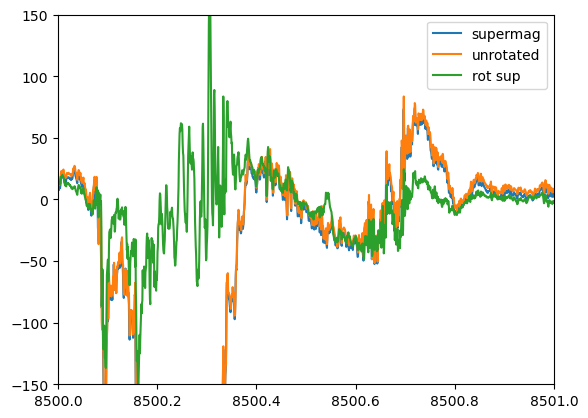

In [ ]:
vardtu, varsup = 'Y', 'dbe_geo'
plt.plot(df_sup['t_mjd'],df_sup[varsup], label='supermag')
plt.plot(df_data['t_mjd'].values[::60],df_data[vardtu].values[::60], label='unrotated')
plt.plot(df_ref['t_mjd'].values[::60],df_ref[vardtu].values[::60]+1, label='rot sup')
#plt.plot(df_test['t_mjd'].values[::60],df_test[vardtu].values[::60], label='rot chaos')
#plt.plot(df_test['t_mjd'].values[::60],Y_rot[::60], ls='--',label='rot chaos 2')
plt.xlim((8500,8501))
plt.ylim((-150,150))
plt.legend()
plt.show()

In [23]:
df_sup = pd.read_csv(f'test_data/supermag_SVS_2025_5.csv')
#df_sup = pd.read_csv(f'supermag_downloads/yearly_baseline/2023/supermag_DMH_2023_2.csv')
df_sup['time'] = pd.to_datetime(df_sup['Date_UTC'])
df_sup['t_mjd'] = datetime_to_mjd2000(df_sup['time'].values)

df_data = pd.read_parquet(f'dtu_downloads/yearly_BASELINE/SVS1/dtu_SVS_2025_5.parquet', engine='fastparquet')
df_data.set_index('time', inplace=True)
df_ref = pd.read_parquet(f'dtu_downloads/yearly_BASELINE_rotated/SVS1/dtu_SVS_2025_5.parquet', engine='fastparquet')

In [27]:
X_rot, Y_rot, theta = rotation_sup(df_data, df_sup)

/tmp/ipykernel_29977/2775845060.py:42: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(Y_ref - Y_rot)


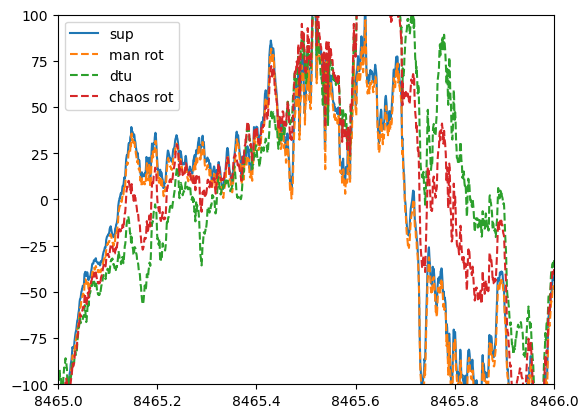

In [22]:
plt.plot(df_sup['t_mjd'],df_sup['dbe_geo'], label='sup')
plt.plot(df_data['t_mjd'].values[::60],Y_rot[::60], ls = '--',label='man rot')
plt.plot(df_data['t_mjd'].values[::60],df_data['Y'].values[::60], ls = '--',label='dtu')
plt.plot(df_ref['t_mjd'].values[::60],df_ref['Y'].values[::60], ls = '--',label='chaos rot')
#plt.plot(df_sup['t_mjd'],df_sup['dbn_nez'], label='nez')

plt.xlim((8465,8466))
plt.ylim((-100,100))
plt.legend()

In [43]:
D = compute_declination(70.48, 338.03, 0, 9300, model)
theta = -D[0] * np.pi/180

Y_nez_rot,X_nez_rot = apply_rotation_manual(df_sup['dbn_nez'].values,df_sup['dbe_nez'].values, -D[0])

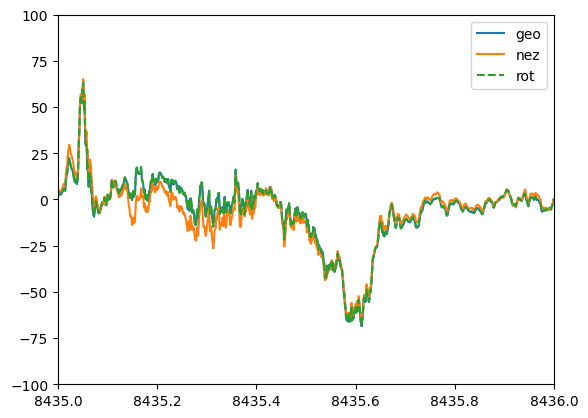

In [44]:
plt.plot(df_sup['t_mjd'],df_sup['dbn_geo'], label='geo')
plt.plot(df_sup['t_mjd'],df_sup['dbn_nez'], label='nez')
plt.plot(df_sup['t_mjd'],X_nez_rot, ls = '--',label='rot')
plt.xlim((8435,8436))
plt.ylim((-100,100))
plt.legend()

**NOTES TO SELF**

PIF ser fin ud som den er, kun 1greds forskel for alle tider, har tjekket 2024 og 2025 også, bare brug det der er lavet allerede

Med dem hvor der slet ikke er noget supermag til sammenligning skal jeg måske også bare bruge det som det er uden at rotere. jeg er i hvert fald kommet i tvivl om hvor godt mon chaos rotation virker og hvilket fortegn jeg skal bruge på deklinationen. nogle gange passer + bedst andre gange -. tror dog mest på +, hvilket IKKE er det jeg har brugt

Nogle gange kan man godt hente data fra supermag website selvom api ikke virker. det gjorde jeg med PIF, kan måske også virke med NRD og SVS f.eks.

når vinkel er -95 er det fordi yearly_BASELINE er ren NaN, har prøvet at genlave nogle filer men får stadig ren NaN

Tror måske bare jeg skal lave manuelle rotationer når jeg kan og ellers lade det være som det er